In [241]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [242]:
df=pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [243]:
new_df=df.drop(['Name','Ticket','Cabin','PassengerId'],axis=1)
new_df

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [244]:

new_df=new_df.drop_duplicates()

temp=new_df.isnull().sum()
print(temp)

new_df['Age']=new_df['Age'].fillna(new_df['Age'].median())
new_df['Embarked']=new_df['Embarked'].fillna(new_df['Embarked'].mode())

print("--------After Replacing Null Value-------")
temp=new_df.isnull().sum()
print(temp)

new_df


Survived      0
Pclass        0
Gender        0
Age         104
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
--------After Replacing Null Value-------
Survived    0
Pclass      0
Gender      0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64


,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [245]:
df_encoded=pd.get_dummies(new_df,dtype=int)
df_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,Gender_female,Gender_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,39.0,0,5,29.1250,1,0,0,1,0
887,1,1,19.0,0,0,30.0000,1,0,0,0,1
888,0,3,28.0,1,2,23.4500,1,0,0,0,1
889,1,1,26.0,0,0,30.0000,0,1,1,0,0


In [246]:
X=df_encoded.drop('Survived',axis=1)
y=df_encoded['Survived']

In [247]:

# Split data into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [248]:
# Initialize and train model
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
dt.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
cm=confusion_matrix(y_test, y_pred_dt)
print(cm)

print(f"TP={cm[0][0]}\nFN={cm[0][1]}\nFP={cm[1][0]}\nTN={cm[1][1]}")

Decision Tree Accuracy: 0.7884615384615384
[[87  4]
 [29 36]]
TP=87
FN=4
FP=29
TN=36


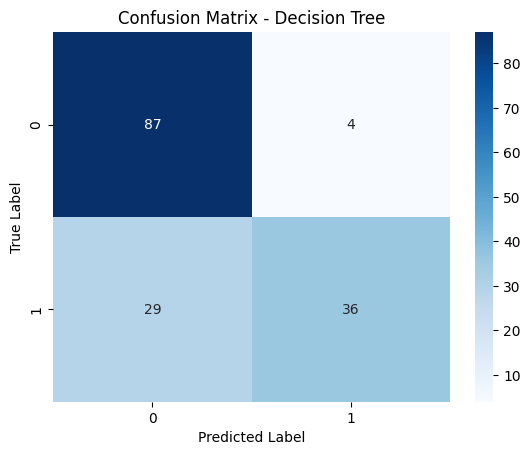

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.96      0.84        91
           1       0.90      0.55      0.69        65

    accuracy                           0.79       156
   macro avg       0.82      0.75      0.76       156
weighted avg       0.81      0.79      0.78       156



In [249]:
# for Decision Tree
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt,))

In [250]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
cm=confusion_matrix(y_test, y_pred_nb)
print(cm)
print(f"TP={cm[0][0]}\nFN={cm[0][1]}\nFP={cm[1][0]}\nTN={cm[1][1]}")

Naive Bayes Accuracy: 0.7756410256410257
[[74 17]
 [18 47]]
TP=74
FN=17
FP=18
TN=47


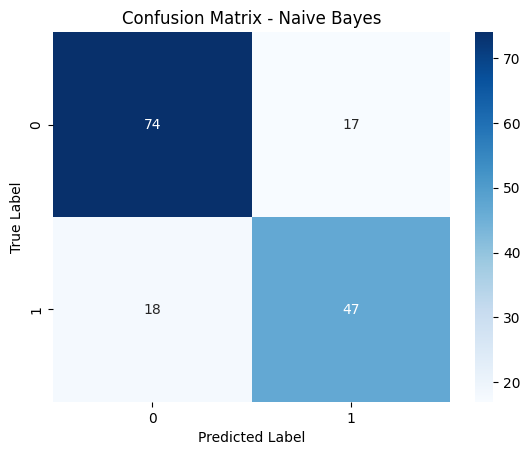

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.81      0.81        91
           1       0.73      0.72      0.73        65

    accuracy                           0.78       156
   macro avg       0.77      0.77      0.77       156
weighted avg       0.78      0.78      0.78       156



In [251]:
# for Naive Bayes
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred_nb,))

In [252]:
# Summary table
models = ['Decision Tree', 'Naive Bayes']
accuracies = [
accuracy_score(y_test, y_pred_dt),
accuracy_score(y_test, y_pred_nb),
]

for m, acc in zip(models, accuracies):
    print(f"{m:20s} Accuracy: {acc*100:.2f}%")

Decision Tree        Accuracy: 78.85%
Naive Bayes          Accuracy: 77.56%


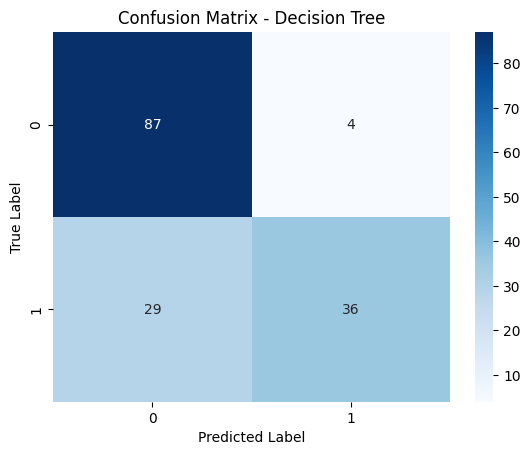

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.96      0.84        91
           1       0.90      0.55      0.69        65

    accuracy                           0.79       156
   macro avg       0.82      0.75      0.76       156
weighted avg       0.81      0.79      0.78       156



In [253]:


# for Decision Tree)
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt,))

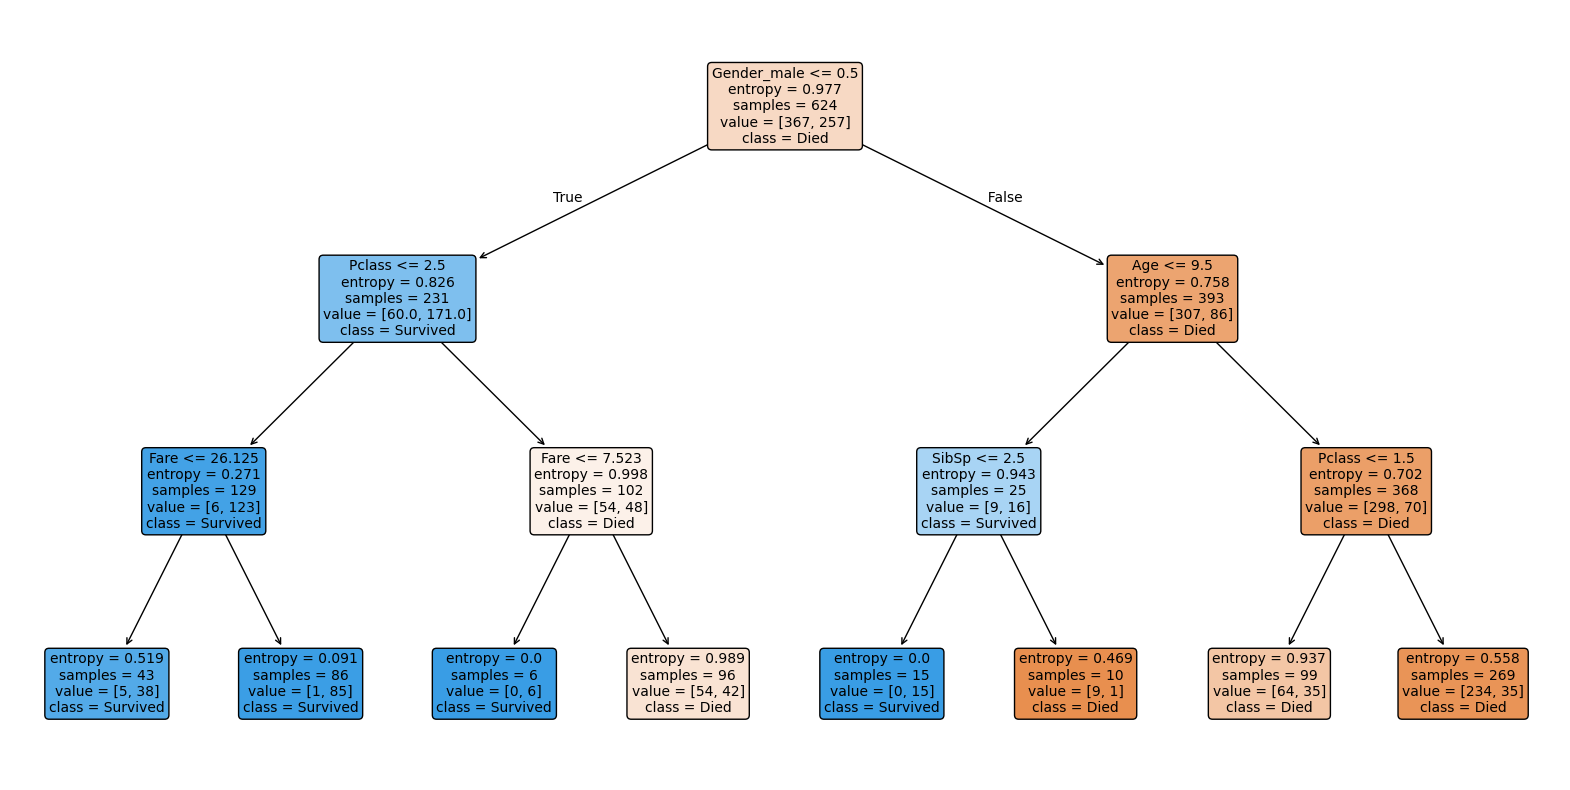

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(dt, 
          feature_names=X.columns,   
          class_names=['Died', 'Survived'],
          filled=True,              
          rounded=True,              
          fontsize=10)

plt.show()

In [255]:

# Split data into 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [256]:
# Initialize and train model
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
dt.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
cm=confusion_matrix(y_test, y_pred_dt)
print(cm)

print(f"TP={cm[0][0]}\nFN={cm[0][1]}\nFP={cm[1][0]}\nTN={cm[1][1]}")

Decision Tree Accuracy: 0.7991452991452992
[[134   5]
 [ 42  53]]
TP=134
FN=5
FP=42
TN=53


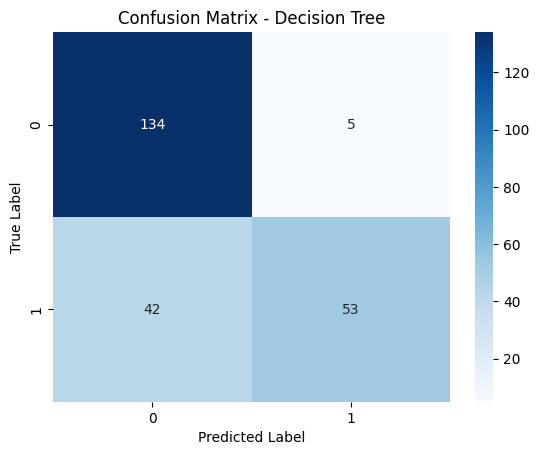

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.96      0.85       139
           1       0.91      0.56      0.69        95

    accuracy                           0.80       234
   macro avg       0.84      0.76      0.77       234
weighted avg       0.82      0.80      0.79       234



In [257]:
# for Decision Tree
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt,))

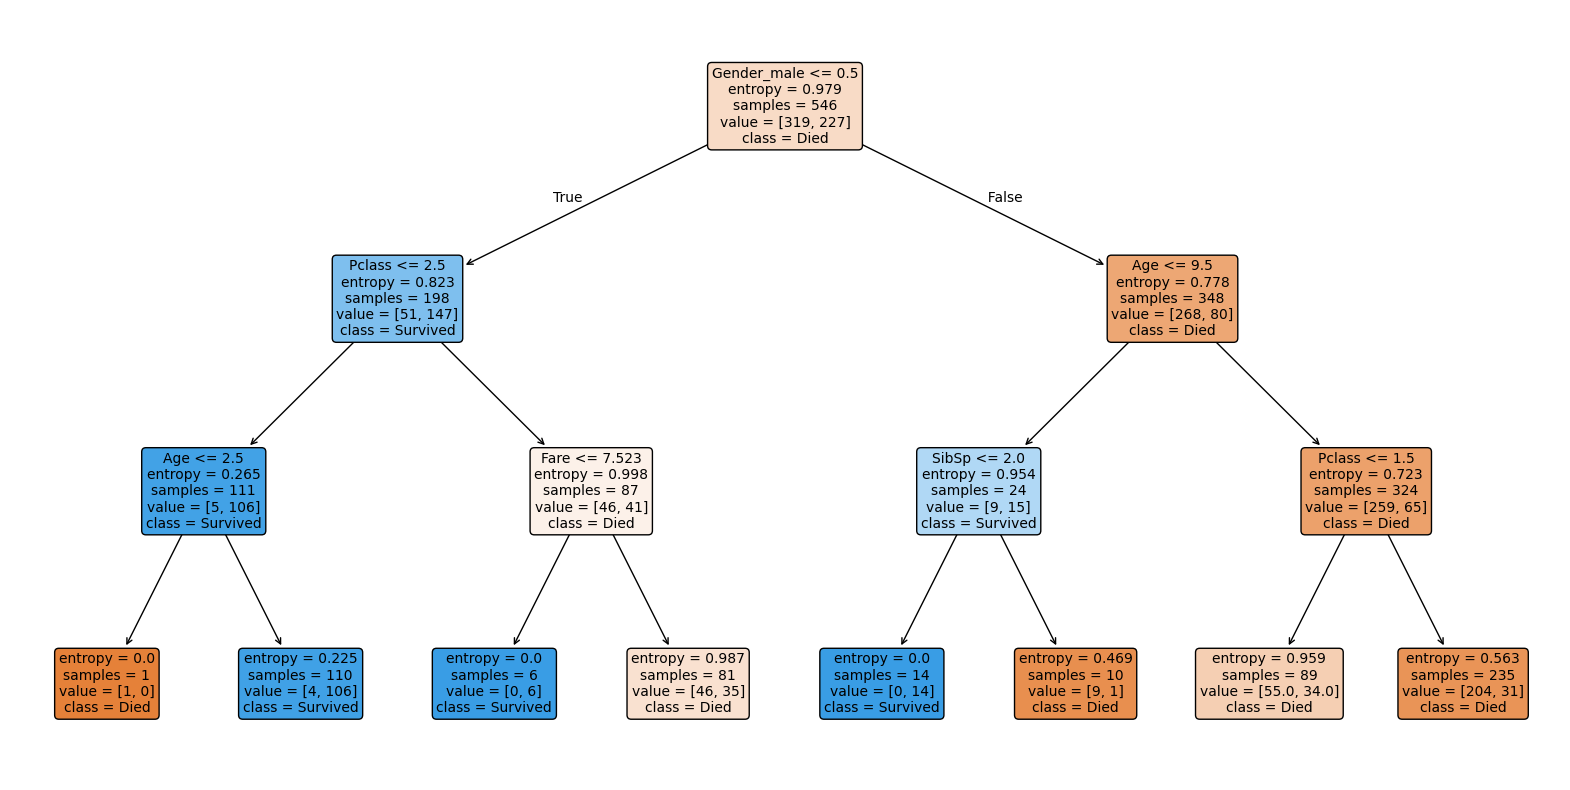

In [258]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(dt, 
          feature_names=X.columns,  
          class_names=['Died', 'Survived'],
          filled=True,               
          rounded=True,            
          fontsize=10)

plt.show()